In [2]:
from langchain_core.prompts import PromptTemplate
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict,Annotated
import os,sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from qdrant_store import qdrant_store
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
class UserInput(TypedDict):
    query: str
    enriched_query: str
    top_results: list[str]
    final_result: str

In [5]:
llm = ChatOpenAI(
    model="openai/gpt-oss-20b:free",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
    temperature=0.7
)


In [6]:
def enriched_query(state: UserInput):
    prompt=PromptTemplate(
        input_variables=["query"],
        template="""
Rewrite the user's question to improve semantic retrieval.

Rules:
- Preserve the original intent.
- Do NOT answer the question.
- Do NOT add unrelated concepts.
- Return only the rewritten query.

Question:
{query}
"""
    )

    formatted_query=prompt.format(query=state['query'])

    response=llm.invoke(formatted_query).content
    return {'enriched_query':response}


def top_results(state: UserInput):
    retreiver=qdrant_store()
    query=state['enriched_query']
    docs=retreiver.invoke(query)
    return {'top_results':[doc.page_content for doc in docs]}

def final_result(state: UserInput):
    prompt=PromptTemplate(
        input_variables=["question","context"],
        template="""
You are an expert AI assistant.

Answer the user's question using ONLY the information provided in the context below.

Instructions:
- Use the retrieved context as the primary source.
- If the answer is fully supported by the context, answer clearly and completely.
- If the context only partially answers the question, say what is supported and mention what is missing.
- If the answer cannot be found in the context, reply:
  "I couldn't find enough information in the provided documents to answer this question."
- Do not make up facts or use outside knowledge.
- Keep the answer well-structured and easy to read.

Context:
{context}

Question:
{question}

Answer:
"""
)
    context_str = "\n\n---\n\n".join(state['top_results'])
    prompt=prompt.format(context=context_str,question=state['enriched_query'])
    response=llm.invoke(prompt).content
    return {'final_result':response}
    

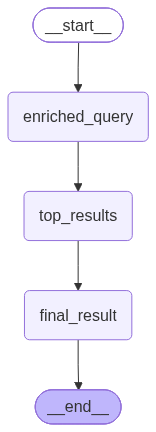

In [7]:
graph=StateGraph(UserInput)

graph.add_node('enriched_query',enriched_query)
graph.add_node('top_results',top_results)
graph.add_node('final_result',final_result)

graph.add_edge(START,'enriched_query')
graph.add_edge('enriched_query','top_results')
graph.add_edge('top_results','final_result')
graph.add_edge('final_result',END)

workflow=graph.compile()
graph.compile()

In [8]:
initial_state={
    'query':"What is RNN?"
}
workflow.invoke(initial_state)


{'query': 'What is RNN?',
 'enriched_query': 'What is a recurrent neural network?',
 'top_results': ['Chapter 21\nRecurrent Neural Networks (RNN)\nA recurrent neural network (RNN) is a class of artiﬁcial neural network where connections\nbetween units form a directed cycle. This creates an internal state of the network which allows\nit to exhibit dynamic temporal behavior. Unlike feedforward neural networks, RNNs can use\ntheir internal memory to process arbitrary sequences of inputs. This makes them applicable to\ntasks such as unsegmented connected handwriting recognition or speech recognition.\nFigure 21.1: RNN\nNotice that the same function and the same set of parameters are used at very time step! We\ncan not have RNNs of enormous length because we have to store in memory the hidden state of',
  'they introduce gradient noise to a layer and show how it evolves. We can see that RNN\nautomatically kills it while LSTM maintains it more time. This means that RNN can not\nlearn long te